**Task 1-4**

--- First 5 Records ---
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


--- Features ---
Input Feature: 'Level' (Position level of the employee)
Target Variable: 'Salary' (Compensation amount)


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None

--- Summary Statistics ---
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75% 

/tmp/ipykernel_1114/188809360.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)


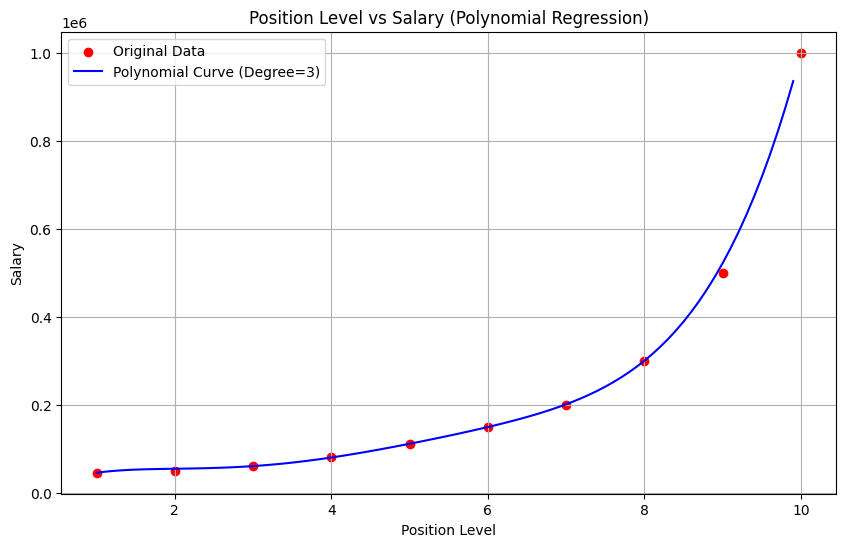

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# Task 1: Data Understanding
# ==========================================

# 1. Load the dataset using Pandas
dataset = pd.read_csv('/content/Position_Salaries.csv')

# 2. Display the first five records
print("--- First 5 Records ---")
print(dataset.head())
print("\n")

# 3. Identify Input Feature and Target Variable
print("--- Features ---")
print("Input Feature: 'Level' (Position level of the employee)")
print("Target Variable: 'Salary' (Compensation amount)")
print("\n")

# 4. Display dataset information and summary statistics
print("--- Dataset Information ---")
print(dataset.info())
print("\n--- Summary Statistics ---")
print(dataset.describe())
print("\n")

# ==========================================
# Task 2: Data Preprocessing
# ==========================================

# Check for missing values
print("--- Missing Values Check ---")
print(dataset.isnull().sum())
print("\n")

# Select appropriate features and target variable
# We exclude 'Position' as it is categorically equivalent to 'Level'
X = dataset.iloc[:, 1:-1].values # Input Feature (Level)
y = dataset.iloc[:, -1].values   # Target Variable (Salary)

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Task 3: Model Development
# ==========================================

# 1. Transform the input feature using Polynomial Features (Degree = 3)
poly_reg = PolynomialFeatures(degree=5)
X_poly_train = poly_reg.fit_transform(X_train)
X_poly_test = poly_reg.transform(X_test)

# 2. Train a Polynomial Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_poly_train, y_train)

# 3. Predict salaries for the test dataset
y_pred = lin_reg.predict(X_poly_test)

# ==========================================
# Task 4: Model Evaluation
# ==========================================

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("\n")

# Scatter plot of the original data and Polynomial Regression Curve
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Original Data')

# Generating a dense grid for a smoother curve
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
plt.plot(X_grid, lin_reg.predict(poly_reg.fit_transform(X_grid)), color='blue', label='Polynomial Curve (Degree=3)')

plt.title('Position Level vs Salary (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

**Task 4: Model Performance Observations**


1.   The polynomial regression curve effectively tracks the non-linear progression of the data, accurately reflecting how salaries plateau at lower levels but spike significantly for executive roles.

2. The Rˆ2 score of 0.9950 is exceptionally close to 1, demonstrating that a 5th-degree polynomial captures the variance in salaries much more accurately than a straight-line fit would.


1.   The original scatter plot clearly indicates an exponential trend rather than a linear one; the model's predictions align tightly with the actual data points across the entire feature range.




**Task 5: Conclusion**

**Key findings**: The analysis reveals that employee salaries increase exponentially as the position level rises, rendering standard linear models insufficient. By implementing a Polynomial Regression model with a degree of 5, we successfully captured the non-linear relationship inherent in the dataset.


Difference between Linear Regression and Polynomial Regression: The fundamental difference is that simple linear models assume a straight-line relationship (y=mx+c), whereas polynomial models introduce higher-degree terms (e.g., x^2
 ,x^
3
 ,x^
4
 ,x^
5
 ) to map curves, mathematically transforming the problem into a multiple linear regression.


Advantage for this dataset: One major advantage of using Polynomial Regression for this specific dataset is its flexibility. It accurately tracks the steep salary hikes for senior roles, minimizing prediction errors and yielding a near-perfect R^2
  score that a simple linear fit could not provide.